# Unified Mixture of Experts — 5G/6G Cross-Generation Attack Detection

---

## Project context

This notebook extends the two preceding pipelines — `Notebook_5G_FINAL.ipynb` (5G-NIDD, supervised classification) and `Notebook-6G-FINAL.ipynb` (AIoT-Sol 6G, one-class anomaly detection) — by combining their outputs into a single **Mixture of Experts (MoE)** model. The MoE can ingest flow records from either generation of the network through a shared feature space.

## Design

The pipeline has three stages trained sequentially (joint training from scratch is unstable and is deliberately avoided):

1. **Unified feature projection** — both cleaned datasets are mapped onto a common schema of 16 generation-agnostic flow primitives (duration, packet counts per direction, byte rates, flag indicators, protocol one-hots).
2. **Per-domain expert training** — five independent experts, each on its native data:
    - Three supervised XGBoost classifiers, one per 5G slice (`eMBB`, `mMTC`, `URLLC`).
    - Two one-class autoencoders, one per 6G protocol (`TCP`, `UDP`), trained on benign flows only.
3. **Gating network + calibrated combiner** — a small MLP learns soft routing weights; expert outputs are calibrated to a common [0,1] attack-probability scale and combined by a weighted sum.

## What is preserved from the original notebooks

- The **cleaned CSV outputs** of both pipelines are used as-is. No re-cleaning is performed.
- The **structured anomaly injection** from the 6G notebook (SYN flood / port scan / DDoS volume / data exfiltration profiles) is reused, adapted to the unified feature space.
- **Evaluation protocol and metrics** mirror the originals: stratified splits, F1, Recall, Precision, AUC-ROC, PR-AUC, confusion matrices, ROC/PR curves.

## What is new

- A **unified projector** that maps Argus-schema rows (5G) and CICFlowMeter-schema rows (6G) into the same 16-dimensional space.
- A **post-projection global scaler** that normalises out scale differences between the two source cleanings.
- A **soft-routing gating network** trained on combined labelled data (frozen experts).
- **Cross-domain evaluation** with gate-weight analysis (showing the gate has actually learned to route by domain).

---
## Section 0 — Imports & Configuration

All libraries needed across the notebook. Random seeds are fixed for reproducibility, and `MODELS_DIR` collects all persisted artefacts at the end.

In [22]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supervised experts (XGBoost) — already used successfully in the 5G notebook
from xgboost import XGBClassifier

# Autoencoders (TensorFlow/Keras) — already used successfully in the 6G notebook
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Preprocessing, splitting, and metric utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # Platt scaling
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, classification_report,
)

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Display & plotting ───────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ── Artefact directory ───────────────────────────────────────────────────
MODELS_DIR = 'moe_artefacts'
os.makedirs(MODELS_DIR, exist_ok=True)

print('✓ Environment ready')
print(f'  TensorFlow : {tf.__version__}')
print(f'  pandas     : {pd.__version__}')
print(f'  numpy      : {np.__version__}')
print(f'  Artefacts will be saved under: {MODELS_DIR}/')

✓ Environment ready
  TensorFlow : 2.19.0
  pandas     : 2.3.3
  numpy      : 2.0.2
  Artefacts will be saved under: moe_artefacts/


---
## Section 1 — Load the two cleaned datasets

These two files are the outputs of the preceding notebooks:

| File | Source notebook | Content | Label convention |
|---|---|---|---|
| `Global_CLEANED.csv` | `Notebook_5G_FINAL.ipynb` | 5G-NIDD Global (all slices pooled) | `0` = Benign, `1` = Attack |
| `AIoT_6G_CLEANED.csv` | `Notebook-6G-FINAL.ipynb` | AIoT-Sol 6G (100% benign) | `'Benign'` string only |

Both files are loaded into memory untouched. Schema inspection follows in the next cell.

In [23]:
# ── Paths — adjust if your files live elsewhere ──────────────────────────
PATH_5G = '/kaggle/input/datasets/seifouarag/dataset/Global_CLEANED.csv'
PATH_6G = '/kaggle/input/datasets/seifouarag/dataset/AIoT_6G_CLEANED.csv'

df_5g_raw = pd.read_csv(PATH_5G)
df_6g_raw = pd.read_csv(PATH_6G)

print('=' * 65)
print('5G dataset (Global_CLEANED.csv)')
print('=' * 65)
print(f'  Shape       : {df_5g_raw.shape}')
print(f'  Label set   : {sorted(df_5g_raw["Label"].unique())}')
print(f'  Label counts:')
print(df_5g_raw['Label'].value_counts().to_string())

print()
print('=' * 65)
print('6G dataset (AIoT_6G_CLEANED.csv)')
print('=' * 65)
print(f'  Shape       : {df_6g_raw.shape}')
print(f'  Label set   : {sorted(df_6g_raw["Label"].unique())}')
print(f'  Label counts:')
print(df_6g_raw['Label'].value_counts().to_string())

5G dataset (Global_CLEANED.csv)
  Shape       : (14456, 56)
  Label set   : [np.int64(0), np.int64(1)]
  Label counts:
Label
1    7399
0    7057

6G dataset (AIoT_6G_CLEANED.csv)
  Shape       : (22560, 54)
  Label set   : ['Benign']
  Label counts:
Label
Benign    22560


**Note on label conventions:**
- 5G's `Label` column was binary-encoded during cleaning: `0 = Benign`, `1 = Malicious`.
- 6G's `Label` column is still the string `'Benign'` (the original cleaning produced a one-class dataset). Synthetic anomalies will be injected downstream, assigning `1` to the perturbed rows.

Both will be harmonised into an integer `y` vector once the data is projected.

---
## Section 2 — Schema inspection

The two cleaning pipelines used **different naming conventions** for transformed features:

- 5G kept the `_log` suffix on log-transformed columns (e.g. `Dur_log`, `TotPkts_log`, `Load_log`).
- 6G overwrote columns in place (e.g. `Flow Duration`, `Total Fwd Packets`, `Flow Bytes/s`).

Before defining the projection, we print the column list of each file so the mapping decisions in the next section are transparent and auditable.

In [24]:
print('5G columns ({}):'.format(len(df_5g_raw.columns)))
for i, col in enumerate(df_5g_raw.columns):
    print(f'  [{i:>2}] {col}')

5G columns (56):
  [ 0] Dur
  [ 1] Mean
  [ 2] Min
  [ 3] Max
  [ 4] sTos_code
  [ 5] dTos_code
  [ 6] sTtl
  [ 7] dTtl
  [ 8] sHops
  [ 9] dHops
  [10] dMeanPktSz
  [11] SrcTCPBase
  [12] DstTCPBase
  [13] AckDat
  [14] Label
  [15] dTos_was_missing
  [16] dTtl_was_missing
  [17] dHops_was_missing
  [18] DstTCPBase_was_missing
  [19] SrcTCPBase_was_missing
  [20] SrcLoss_ratio
  [21] Load_log
  [22] SrcLoad_log
  [23] Rate_log
  [24] SynAck_log
  [25] TcpRtt_log
  [26] SrcBytes_log
  [27] Loss_log
  [28] SrcPkts_log
  [29] sMeanPktSz_log
  [30] TotBytes_log
  [31] pLoss_log
  [32] Offset_log
  [33] TotPkts_log
  [34] SrcWin_log
  [35] DstWin_log
  [36] Proto_lldp
  [37] Proto_sctp
  [38] Proto_tcp
  [39] Proto_udp
  [40] State_CON
  [41] State_ECO
  [42] State_FIN
  [43] State_INT
  [44] State_REQ
  [45] State_RST
  [46] State_URP
  [47] Cause_Start
  [48] Cause_Status
  [49] dDSb_af12
  [50] dDSb_cs0
  [51] dDSb_ef
  [52] dDSb_unknown
  [53] sDSb_is_cs0
  [54] slice_2:mMTC
  [55] sli

In [25]:
print('6G columns ({}):'.format(len(df_6g_raw.columns)))
for i, col in enumerate(df_6g_raw.columns):
    print(f'  [{i:>2}] {col}')

6G columns (54):
  [ 0] Flow Duration
  [ 1] Total Fwd Packets
  [ 2] Total Backward Packets
  [ 3] Fwd Packet Length Max
  [ 4] Fwd Packet Length Min
  [ 5] Fwd Packet Length Mean
  [ 6] Bwd Packet Length Max
  [ 7] Bwd Packet Length Min
  [ 8] Bwd Packet Length Mean
  [ 9] Flow Bytes/s
  [10] Flow Packets/s
  [11] Flow IAT Mean
  [12] Flow IAT Std
  [13] Flow IAT Max
  [14] Flow IAT Min
  [15] Fwd IAT Mean
  [16] Fwd IAT Std
  [17] Fwd IAT Min
  [18] Bwd IAT Mean
  [19] Bwd IAT Std
  [20] Bwd IAT Min
  [21] Fwd PSH Flags
  [22] Fwd Header Length
  [23] Bwd Header Length
  [24] Packet Length Mean
  [25] FIN Flag Count
  [26] SYN Flag Count
  [27] RST Flag Count
  [28] PSH Flag Count
  [29] Down/Up Ratio
  [30] Bwd Avg Bytes/Bulk
  [31] Bwd Avg Bulk Rate
  [32] Subflow Fwd Packets
  [33] Subflow Fwd Bytes
  [34] Subflow Bwd Packets
  [35] Init_Win_bytes_forward
  [36] Init_Win_bytes_backward
  [37] min_seg_size_forward
  [38] Active Mean
  [39] Active Std
  [40] Idle Std
  [41] Port_0


---
## Section 3 — Unified feature projection

### The 16 unified primitives

| # | Unified name | Semantics | 5G source (Argus) | 6G source (CICFlowMeter) |
|---|---|---|---|---|
| 1 | `u_duration` | Flow duration | `Dur_log` or `Dur` | `Flow Duration` |
| 2 | `u_fwd_pkts` | Forward packet count | `SrcPkts_log` or `SrcPkts` | `Total Fwd Packets` |
| 3 | `u_bwd_pkts` | Backward packet count | `DstPkts_log` or `DstPkts` | `Total Backward Packets` |
| 4 | `u_fwd_mean_size` | Mean forward packet size | `sMeanPktSz_log` or `sMeanPktSz` | `Fwd Packet Length Mean` |
| 5 | `u_bwd_mean_size` | Mean backward packet size | `dMeanPktSz_log` or `dMeanPktSz` | `Bwd Packet Length Mean` |
| 6 | `u_byte_rate` | Bytes per second | `Load_log` or `Load` | `Flow Bytes/s` |
| 7 | `u_pkt_rate` | Packets per second | `Rate_log` or `Rate` | `Flow Packets/s` |
| 8 | `u_pkt_ratio` | fwd / (fwd + bwd) | derived | derived |
| 9 | `u_size_ratio` | fwd_size / (fwd_size + bwd_size) | derived | derived |
| 10 | `u_syn` | SYN flag active (binary) | from `State` flags | `SYN Flag Count > 0` |
| 11 | `u_fin` | FIN flag active (binary) | from `State` flags | `FIN Flag Count > 0` |
| 12 | `u_rst` | RST flag active (binary) | from `State` flags | `RST Flag Count > 0` |
| 13 | `u_psh` | PSH flag active (binary) | from `State` flags | `PSH Flag Count > 0` |
| 14 | `u_is_tcp` | Protocol = TCP (binary) | `Proto == 'tcp'` | `Proto_TCP` |
| 15 | `u_is_udp` | Protocol = UDP (binary) | `Proto == 'udp'` | `Proto_UDP` |
| 16 | `u_is_other` | Protocol = neither (binary) | otherwise | `Proto_Other` |

### Key design decisions

- **Ratios rather than raw sums** where possible — `u_pkt_ratio` and `u_size_ratio` are dimensionless and more comparable across the two capture tools.
- **Binary flag indicators** rather than raw counts — aligns the Argus `State` string encoding with CICFlowMeter's `* Flag Count` integers while preserving the attack-relevant signal (whether a flag was seen at all).
- **Protocol one-hot** retained — TCP/UDP/Other behave differently enough that the experts and gate benefit from explicit protocol awareness.

The defensive helper below accepts a list of candidate column names and returns the first one that exists. This tolerates minor differences between your actual cleaned files and the expected names.

In [26]:
def first_available(df, candidates):
    """
    Return the first column name in `candidates` that exists in df.columns.
    Returns None if none match. Useful for handling naming variants
    (e.g. 'Dur_log' vs 'Dur') without hand-editing the projector.
    """
    for c in candidates:
        if c in df.columns:
            return c
    return None


def extract_5g_flags(df):
    """
    Derive binary SYN/FIN/RST/PSH indicators from the 5G cleaned schema.
    
    After cleaning, `State` was one-hot encoded. Columns of the form
    `State_*` each encode a termination/control code. We produce a
    binary indicator per TCP flag by matching substrings. If no `State_*`
    columns are present (e.g. schema variant), the flag is returned as 0.
    """
    state_cols = [c for c in df.columns if c.startswith('State_')]
    out = pd.DataFrame(index=df.index)
    for flag_name, subs in [('u_syn', ['SYN', 'S_']),
                             ('u_fin', ['FIN', 'F_']),
                             ('u_rst', ['RST', 'R_']),
                             ('u_psh', ['PSH', 'P_'])]:
            matched = [c for c in state_cols
                       if any(s in c.upper() for s in subs)]
            if matched:
                out[flag_name] = (df[matched].sum(axis=1) > 0).astype(int)
            else:
                out[flag_name] = 0
    return out

### Projector for the 5G dataset

We map each of the 16 unified features from the available cleaned columns, falling back gracefully when a column is absent. The derived features (`u_pkt_ratio`, `u_size_ratio`) are computed from the already-log-transformed values, which is acceptable because ratios of log-transformed quantities remain informative (they measure relative magnitude, even if not in the original linear scale).

In [28]:
def project_5g(df):
    """Map the cleaned 5G dataframe onto the 16-feature unified schema."""
    out = pd.DataFrame(index=df.index)
    
    # Numeric primitives — each has two candidates (log and raw name)
    col_dur     = first_available(df, ['Dur_log', 'Dur'])
    col_fwd_pk  = first_available(df, ['SrcPkts_log', 'SrcPkts'])
    col_fwd_sz  = first_available(df, ['sMeanPktSz_log', 'sMeanPktSz'])
    col_bwd_sz  = first_available(df, ['dMeanPktSz_log', 'dMeanPktSz'])
    col_byte_rt = first_available(df, ['Load_log', 'Load', 'SrcLoad_log', 'SrcLoad'])
    col_pkt_rt  = first_available(df, ['Rate_log', 'Rate', 'SrcRate_log', 'SrcRate'])
    
    # Backward packet count — the 5G cleaning pipeline drops DstPkts as
    # correlated with TotPkts, so we reconstruct it from TotPkts - SrcPkts
    # in linear space, then re-log.
    col_bwd_pk  = first_available(df, ['DstPkts_log', 'DstPkts'])
    col_tot_pk  = first_available(df, ['TotPkts_log', 'TotPkts'])
    
    # Assign — use 0 fallback if a column is missing entirely
    out['u_duration']       = df[col_dur].values     if col_dur     else 0.0
    out['u_fwd_pkts']       = df[col_fwd_pk].values  if col_fwd_pk  else 0.0
    out['u_fwd_mean_size']  = df[col_fwd_sz].values  if col_fwd_sz  else 0.0
    out['u_bwd_mean_size']  = df[col_bwd_sz].values  if col_bwd_sz  else 0.0
    out['u_byte_rate']      = df[col_byte_rt].values if col_byte_rt else 0.0
    out['u_pkt_rate']       = df[col_pkt_rt].values  if col_pkt_rt  else 0.0
    
    # u_bwd_pkts: prefer direct column; otherwise reconstruct from tot - fwd
    if col_bwd_pk:
        out['u_bwd_pkts'] = df[col_bwd_pk].values
    elif col_tot_pk and col_fwd_pk:
        tot_lin = np.expm1(df[col_tot_pk].values) if col_tot_pk.endswith('_log') else df[col_tot_pk].values
        fwd_lin = np.expm1(df[col_fwd_pk].values) if col_fwd_pk.endswith('_log') else df[col_fwd_pk].values
        bwd_lin = np.clip(tot_lin - fwd_lin, a_min=0.0, a_max=None)
        out['u_bwd_pkts'] = np.log1p(bwd_lin)
    else:
        out['u_bwd_pkts'] = 0.0
    
    # Ratios (add small ε to avoid division by zero)
    eps = 1e-6
    fwd_pk = out['u_fwd_pkts'].abs() + eps
    bwd_pk = out['u_bwd_pkts'].abs() + eps
    out['u_pkt_ratio']  = fwd_pk / (fwd_pk + bwd_pk)
    fwd_sz = out['u_fwd_mean_size'].abs() + eps
    bwd_sz = out['u_bwd_mean_size'].abs() + eps
    out['u_size_ratio'] = fwd_sz / (fwd_sz + bwd_sz)
    
    # Flags — derived from State_* OHE columns
    out = pd.concat([out, extract_5g_flags(df)], axis=1)
    
    # Protocol one-hot — Proto was OHE'd during cleaning into Proto_tcp / Proto_udp / ...
    proto_cols = [c for c in df.columns if c.lower().startswith('proto_')]
    out['u_is_tcp']   = 0
    out['u_is_udp']   = 0
    out['u_is_other'] = 0
    for c in proto_cols:
        if 'tcp' in c.lower():
            out['u_is_tcp']   = (out['u_is_tcp']   | (df[c] > 0).astype(int))
        elif 'udp' in c.lower():
            out['u_is_udp']   = (out['u_is_udp']   | (df[c] > 0).astype(int))
        else:
            out['u_is_other'] = (out['u_is_other'] | (df[c] > 0).astype(int))
    
    # Ensure at least one protocol column is set per row (default to 'other')
    none_set = (out[['u_is_tcp', 'u_is_udp', 'u_is_other']].sum(axis=1) == 0)
    out.loc[none_set, 'u_is_other'] = 1
    
    return out

### Apply the projections

Both projectors are run. The outputs are two clean dataframes, each with exactly 16 columns in the canonical order. A summary print verifies that no NaN / Inf values slipped through and that the shapes match the expected row counts.

In [29]:
X_5g = project_5g(df_5g_raw)[UNIFIED_FEATURES].astype(np.float32)
X_6g = project_6g(df_6g_raw)[UNIFIED_FEATURES].astype(np.float32)

# Target vectors — harmonise to integer labels
y_5g = df_5g_raw['Label'].astype(int).values           # already 0/1
y_6g = np.zeros(len(X_6g), dtype=int)                   # 6G is 100% benign

print('Projection complete')
print(f'  5G unified : shape={X_5g.shape},  NaN={X_5g.isna().sum().sum()},  Inf={np.isinf(X_5g.values).sum()}')
print(f'  6G unified : shape={X_6g.shape},  NaN={X_6g.isna().sum().sum()},  Inf={np.isinf(X_6g.values).sum()}')
print()
print('5G unified preview:')
print(X_5g.head(3).to_string())
print()
print('6G unified preview:')
print(X_6g.head(3).to_string())

Projection complete
  5G unified : shape=(14456, 16),  NaN=0,  Inf=0
  6G unified : shape=(22560, 16),  NaN=0,  Inf=0

5G unified preview:
   u_duration  u_fwd_pkts  u_bwd_pkts  u_fwd_mean_size  u_bwd_mean_size  u_byte_rate  u_pkt_rate  u_pkt_ratio  u_size_ratio  u_syn  u_fin  u_rst  u_psh  u_is_tcp  u_is_udp  u_is_other
0      0.0003      0.6931      0.6931           0.5290          60.0000       0.0000      5.5782       0.5000        0.0087 0.0000 0.0000 0.0000 0.0000    0.0000    1.0000      0.0000
1      0.0000      0.6931      0.0000           0.5318           0.0000       0.0000      0.0000       1.0000        1.0000 0.0000 0.0000 0.0000 0.0000    0.0000    1.0000      0.0000
2      2.5603      1.0986      0.0000           0.5194           0.0000       4.8846      0.3297       1.0000        1.0000 0.0000 0.0000 0.0000 0.0000    0.0000    1.0000      0.0000

6G unified preview:
   u_duration  u_fwd_pkts  u_bwd_pkts  u_fwd_mean_size  u_bwd_mean_size  u_byte_rate  u_pkt_rate  u_pkt_

In [30]:
# Replace any residual NaN/Inf (can appear in ratio features when both inputs are zero)
for X in (X_5g, X_6g):
    X.replace([np.inf, -np.inf], 0.0, inplace=True)
    X.fillna(0.0, inplace=True)

print('✓ NaN/Inf sanitised')
print(f'  5G post-clean: NaN={X_5g.isna().sum().sum()}, Inf={np.isinf(X_5g.values).sum()}')
print(f'  6G post-clean: NaN={X_6g.isna().sum().sum()}, Inf={np.isinf(X_6g.values).sum()}')

✓ NaN/Inf sanitised
  5G post-clean: NaN=0, Inf=0
  6G post-clean: NaN=0, Inf=0


---
## Section 4 — Global post-projection scaling

Because the 5G cleaning pipeline log-transforms numeric features without rescaling, while the 6G pipeline both log-transforms and applies `StandardScaler`, the raw unified values across the two sources live on different scales. We fit one final `StandardScaler` on the **combined** 5G+6G unified features so that every numeric feature has zero mean and unit variance across the whole population.

**Binary features are excluded from scaling** — rescaling 0/1 flags would centre them at ~0.3 and destroy the threshold-at-0 semantics. This mirrors the exclusion logic used in both original cleaning pipelines.

In [31]:
# Binary columns excluded from scaling
BINARY_FEATS = ['u_syn', 'u_fin', 'u_rst', 'u_psh',
                'u_is_tcp', 'u_is_udp', 'u_is_other']
NUMERIC_FEATS = [f for f in UNIFIED_FEATURES if f not in BINARY_FEATS]

print(f'Numeric features to scale   : {len(NUMERIC_FEATS)}')
print(f'Binary features kept as-is  : {len(BINARY_FEATS)}')

# Fit on the union of both domains → a single coherent reference distribution
X_combined = pd.concat([X_5g[NUMERIC_FEATS], X_6g[NUMERIC_FEATS]], axis=0)
unified_scaler = StandardScaler().fit(X_combined.values)

# Transform each domain independently using the same fitted scaler
X_5g_sc = X_5g.copy()
X_6g_sc = X_6g.copy()
X_5g_sc[NUMERIC_FEATS] = unified_scaler.transform(X_5g[NUMERIC_FEATS].values)
X_6g_sc[NUMERIC_FEATS] = unified_scaler.transform(X_6g[NUMERIC_FEATS].values)

print()
print('After global scaling:')
print(f'  5G mean/std (numeric) : {X_5g_sc[NUMERIC_FEATS].values.mean():+.3f} / {X_5g_sc[NUMERIC_FEATS].values.std():.3f}')
print(f'  6G mean/std (numeric) : {X_6g_sc[NUMERIC_FEATS].values.mean():+.3f} / {X_6g_sc[NUMERIC_FEATS].values.std():.3f}')

Numeric features to scale   : 9
Binary features kept as-is  : 7

After global scaling:
  5G mean/std (numeric) : +0.579 / 1.053
  6G mean/std (numeric) : -0.371 / 0.760


---
## Section 5 — 5G splits: per-slice stratified partitioning

Each 5G row belongs to exactly one network slice (`eMBB`, `mMTC`, or `URLLC`), encoded in the `predicted` column. For the MoE:

- Each slice's rows are split into 70% train / 15% val / 15% test, stratified on `Label` to preserve the benign/attack ratio.
- The per-slice **train** partition is used to train that slice's expert XGBoost.
- The per-slice **val** partition contributes to the calibration and gating-network training sets.
- The per-slice **test** partition is held out for final evaluation.

In [33]:
# ── Recover slice identity from the 5G cleaned schema ────────────────────
#
# The 5G cleaning used drop_first=True on the `predicted` column, producing
# two columns: `slice_2:mMTC` and `slice_3:URLLC`. The third slice (eMBB)
# is the implicit reference category — rows where BOTH slice columns = 0.
# (Some older variants of the cleaning used the prefix `predicted_*` rather
# than `slice_*`, so both patterns are supported.)

slice_cols = [c for c in df_5g_raw.columns
              if c.lower().startswith(('slice_', 'predicted_'))]
print(f'Detected slice columns : {slice_cols}')

if len(slice_cols) == 0:
    raise RuntimeError(
        'No slice columns found. Expected names starting with "slice_" '
        'or "predicted_". Check the 5G cleaning output.'
    )

def detect_slice_row(row):
    for c in slice_cols:
        if row[c] == 1:
            c_low = c.lower()
            if 'mmtc' in c_low:  return 'mMTC'
            if 'urllc' in c_low: return 'URLLC'
            if 'embb' in c_low:  return 'eMBB'
    return 'eMBB'   # implicit reference (drop_first=True)

slice_id = df_5g_raw[slice_cols].apply(detect_slice_row, axis=1).values

print()
print('Slice distribution in 5G:')
unique, counts = np.unique(slice_id, return_counts=True)
for s, c in zip(unique, counts):
    print(f'  {s:<6}: {c:>6}  ({c/len(slice_id)*100:.1f}%)')

Detected slice columns : ['slice_2:mMTC', 'slice_3:URLLC']

Slice distribution in 5G:
  URLLC :   4033  (27.9%)
  eMBB  :   5808  (40.2%)
  mMTC  :   4615  (31.9%)


In [34]:
# ── Per-slice stratified 70/15/15 split ──────────────────────────────────
slice_data = {}   # slice_name -> {'train':(X,y), 'val':(X,y), 'test':(X,y)}

for slice_name in ['eMBB', 'mMTC', 'URLLC']:
    mask = (slice_id == slice_name)
    if mask.sum() < 30:
        print(f'⚠  {slice_name}: only {mask.sum()} rows — too few for a 3-way split, skipped')
        continue
    
    X_s = X_5g_sc[mask].values.astype(np.float32)
    y_s = y_5g[mask]
    
    # 85/15 first (carve test)
    X_tv, X_te, y_tv, y_te = train_test_split(
        X_s, y_s, test_size=0.15, random_state=SEED, stratify=y_s
    )
    # Then 70/15 of the original → test_size within tv ≈ 15/85
    X_tr, X_vl, y_tr, y_vl = train_test_split(
        X_tv, y_tv, test_size=15/85, random_state=SEED, stratify=y_tv
    )
    
    slice_data[slice_name] = {
        'train': (X_tr, y_tr),
        'val':   (X_vl, y_vl),
        'test':  (X_te, y_te),
    }
    print(f'{slice_name:<6}: train={X_tr.shape[0]}  val={X_vl.shape[0]}  test={X_te.shape[0]}  '
          f'(attack rate train={y_tr.mean():.2%}, test={y_te.mean():.2%})')

eMBB  : train=4064  val=872  test=872  (attack rate train=47.96%, test=47.94%)
mMTC  : train=3229  val=693  test=693  (attack rate train=46.67%, test=46.61%)
URLLC : train=2823  val=605  test=605  (attack rate train=61.03%, test=60.99%)


---
## Section 6 — 6G splits + structured anomaly injection

The 6G dataset is 100% benign. To evaluate anomaly detection we reuse the **attack-profile injection** from the 6G notebook, adapted to the unified feature space. Each injected anomaly targets only the features relevant to the attack type — this is more realistic than uniform Gaussian noise across all features.

Splits are stratified by protocol (TCP vs UDP, with 'Other' collapsed into the TCP group because it is too small to train an expert on):

- **Per-protocol train** (benign only) → trains the autoencoder for that protocol.
- **Per-protocol val** (benign + injected anomalies) → feeds calibration and gate training.
- **Per-protocol test** (benign + injected anomalies) → final evaluation.

In [37]:
ATTACK_PROFILES = {
    'SYN Flood': {
        'features': ['u_syn', 'u_pkt_rate', 'u_duration'],
        'multiplier': 8.0,
    },
    'Port Scan': {
        'features': ['u_rst', 'u_duration', 'u_pkt_ratio'],
        'multiplier': 6.0,
    },
    'DDoS Volume': {
        'features': ['u_byte_rate', 'u_pkt_rate', 'u_fwd_pkts'],
        'multiplier': 10.0,
    },
    'Data Exfiltration': {
        'features': ['u_bwd_mean_size', 'u_byte_rate'],
        'multiplier': 5.0,
    },
}


def inject_unified_anomalies(X, y, feature_names,
                              anomaly_fraction=0.15, seed=42):
    """
    Perturb a random 15% of rows with attack-type-specific noise.
    X : (n, d) float32 array in the unified scaled space
    y : (n,)  integer array of labels (0 = benign)
    Returns (X_out, y_out) copies with perturbations applied.
    """
    rng = np.random.RandomState(seed)
    X_out = X.copy()
    y_out = y.copy()
    n_anom = int(anomaly_fraction * len(X))
    if n_anom == 0:
        return X_out, y_out
    
    idx_to_attack = rng.choice(len(X), n_anom, replace=False)
    profile_names = list(ATTACK_PROFILES.keys())
    
    for row_idx in idx_to_attack:
        prof = ATTACK_PROFILES[profile_names[rng.randint(len(profile_names))]]
        feat_idx = [feature_names.index(f) for f in prof['features']
                    if f in feature_names]
        if not feat_idx:
            continue
        # Add Gaussian noise scaled by attack multiplier
        noise = rng.normal(0.0, prof['multiplier'], len(feat_idx)).astype(np.float32)
        X_out[row_idx, feat_idx] += noise
        y_out[row_idx] = 1
    
    return X_out, y_out

In [38]:
# ── Recover slice identity from the 5G cleaned schema ────────────────────
#
# The 5G cleaning used drop_first=True on the `predicted` column, producing
# two columns: `slice_2:mMTC` and `slice_3:URLLC`. The third slice (eMBB)
# is the implicit reference category — rows where BOTH slice columns = 0.
# (Some older variants of the cleaning used the prefix `predicted_*` rather
# than `slice_*`, so both patterns are supported.)

slice_cols = [c for c in df_5g_raw.columns
              if c.lower().startswith(('slice_', 'predicted_'))]
print(f'Detected slice columns : {slice_cols}')

if len(slice_cols) == 0:
    raise RuntimeError(
        'No slice columns found. Expected names starting with "slice_" '
        'or "predicted_". Check the 5G cleaning output.'
    )

# Build a string slice_id per row. eMBB is the fallback — rows where
# neither slice_2 nor slice_3 flag is set.
def detect_slice_row(row):
    for c in slice_cols:
        if row[c] == 1:
            c_low = c.lower()
            if 'mmtc' in c_low:  return 'mMTC'
            if 'urllc' in c_low: return 'URLLC'
            if 'embb' in c_low:  return 'eMBB'
    return 'eMBB'   # implicit reference (drop_first=True)

slice_id = df_5g_raw[slice_cols].apply(detect_slice_row, axis=1).values

print()
print('Slice distribution in 5G:')
unique, counts = np.unique(slice_id, return_counts=True)
for s, c in zip(unique, counts):
    print(f'  {s:<6}: {c:>6}  ({c/len(slice_id)*100:.1f}%)')

Detected slice columns : ['slice_2:mMTC', 'slice_3:URLLC']

Slice distribution in 5G:
  URLLC :   4033  (27.9%)
  eMBB  :   5808  (40.2%)
  mMTC  :   4615  (31.9%)


---
## Section 7 — Stage 1a: train 5G slice experts (supervised)

Three XGBoost classifiers, one per slice. Hyper-parameters mirror those that worked well in the 5G notebook (shallow trees with `scale_pos_weight` for residual class imbalance). Each expert only sees its own slice's training data.

In [39]:
def train_slice_expert(X_tr, y_tr, name, seed=SEED):
    """Fit an XGBoost classifier on one 5G slice."""
    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    scale_pos = max(neg / max(pos, 1), 1e-3)
    
    clf = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        random_state=seed,
        n_jobs=-1,
        use_label_encoder=False,
    )
    clf.fit(X_tr, y_tr)
    print(f'  ✓ {name} expert trained — neg/pos = {neg}/{pos}, scale_pos_weight = {scale_pos:.3f}')
    return clf


slice_experts = {}
print('Training 5G slice experts:')
for sl in ['eMBB', 'mMTC', 'URLLC']:
    if sl not in slice_data:
        print(f'  {sl:<6}: no data — skipped')
        continue
    X_tr, y_tr = slice_data[sl]['train']
    slice_experts[sl] = train_slice_expert(X_tr, y_tr, sl)

Training 5G slice experts:
  ✓ eMBB expert trained — neg/pos = 2115/1949, scale_pos_weight = 1.085
  ✓ mMTC expert trained — neg/pos = 1722/1507, scale_pos_weight = 1.143
  ✓ URLLC expert trained — neg/pos = 1100/1723, scale_pos_weight = 0.638


---
## Section 8 — Stage 1b: train 6G protocol experts (one-class)

Two small autoencoders, one for TCP and one for UDP, each trained only on benign flows from its protocol. The architecture (`16 → 10 → 6 → 10 → 16`) is deliberately small — the unified schema is only 16-dimensional and the 6G dataset is not large, so a heavy network would overfit.

Reconstruction error (MSE) is the raw anomaly score. It is converted to a calibrated probability in Section 10.

In [40]:
def build_autoencoder(input_dim, bottleneck=6):
    inp = Input(shape=(input_dim,), name='input')
    x   = Dense(10, activation='relu')(inp)
    x   = BatchNormalization()(x)
    x   = Dropout(0.2)(x)
    bn  = Dense(bottleneck, activation='relu', name='bottleneck')(x)
    x   = Dense(10, activation='relu')(bn)
    x   = BatchNormalization()(x)
    x   = Dropout(0.2)(x)
    out = Dense(input_dim, activation='linear', name='output')(x)
    ae  = Model(inp, out, name='Autoencoder')
    ae.compile(optimizer=Adam(1e-3), loss='mse')
    return ae


def train_ae(X_tr, name, epochs=80, batch=64):
    ae = build_autoencoder(X_tr.shape[1])
    callbacks = [
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6, monitor='val_loss'),
    ]
    ae.fit(X_tr, X_tr,
           epochs=epochs, batch_size=batch,
           validation_split=0.15,
           callbacks=callbacks, verbose=0)
    final_loss = ae.evaluate(X_tr, X_tr, verbose=0)
    print(f'  ✓ {name} AE trained — final train MSE = {final_loss:.4f}')
    return ae


proto_experts = {}
print('Training 6G protocol experts (autoencoders):')
for proto in ['TCP', 'UDP']:
    if proto not in proto_data:
        print(f'  {proto:<6}: no data — skipped')
        continue
    X_tr, _ = proto_data[proto]['train']
    proto_experts[proto] = train_ae(X_tr, proto)

Training 6G protocol experts (autoencoders):
  ✓ TCP AE trained — final train MSE = 0.0556
  UDP   : no data — skipped


---
## Section 9 — Per-expert baseline evaluation

Before wiring the experts together through the gate, we establish **how well each expert performs alone on its native test data**. This serves two purposes: it validates that each expert has learned something useful, and it provides a baseline the MoE should match or exceed.

In [41]:
def eval_classifier(clf, X_te, y_te, name):
    """Evaluate a supervised classifier on its native test split."""
    proba = clf.predict_proba(X_te)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return {
        'expert':     name,
        'n_test':     len(y_te),
        'accuracy':   accuracy_score(y_te, pred),
        'precision':  precision_score(y_te, pred, zero_division=0),
        'recall':     recall_score(y_te, pred, zero_division=0),
        'f1':         f1_score(y_te, pred, zero_division=0),
        'auc_roc':    roc_auc_score(y_te, proba) if len(np.unique(y_te)) > 1 else float('nan'),
        'pr_auc':     average_precision_score(y_te, proba) if len(np.unique(y_te)) > 1 else float('nan'),
    }


def eval_ae(ae, X_te, y_te, name, threshold=None):
    """Evaluate an AE on its native test split using reconstruction error."""
    recon = ae.predict(X_te, verbose=0)
    mse   = np.mean((X_te - recon) ** 2, axis=1)
    if threshold is None:
        # Default threshold: 99th percentile of benign MSE on val set
        threshold = np.percentile(mse[y_te == 0], 99) if (y_te == 0).sum() > 10 else mse.mean()
    pred  = (mse > threshold).astype(int)
    return {
        'expert':     name,
        'n_test':     len(y_te),
        'threshold':  float(threshold),
        'accuracy':   accuracy_score(y_te, pred),
        'precision':  precision_score(y_te, pred, zero_division=0),
        'recall':     recall_score(y_te, pred, zero_division=0),
        'f1':         f1_score(y_te, pred, zero_division=0),
        'auc_roc':    roc_auc_score(y_te, mse) if len(np.unique(y_te)) > 1 else float('nan'),
        'pr_auc':     average_precision_score(y_te, mse) if len(np.unique(y_te)) > 1 else float('nan'),
    }


baseline_rows = []
for sl, clf in slice_experts.items():
    X_te, y_te = slice_data[sl]['test']
    baseline_rows.append(eval_classifier(clf, X_te, y_te, f'5G {sl}'))

for proto, ae in proto_experts.items():
    X_te, y_te = proto_data[proto]['test_aug']
    baseline_rows.append(eval_ae(ae, X_te, y_te, f'6G {proto} AE'))

baseline_df = pd.DataFrame(baseline_rows).set_index('expert')
print('Per-expert baseline (each on its own test set):')
print(baseline_df.round(4).to_string())

Per-expert baseline (each on its own test set):
           n_test  accuracy  precision  recall     f1  auc_roc  pr_auc  threshold
expert                                                                           
5G eMBB       872    0.9392     0.9294  0.9450 0.9371   0.9897  0.9890        NaN
5G mMTC       693    0.9582     0.9594  0.9505 0.9549   0.9885  0.9857        NaN
5G URLLC      605    0.6826     0.8969  0.5420 0.6757   0.8544  0.8906        NaN
6G TCP AE    3384    0.9902     0.9455  0.9921 0.9682   0.9992  0.9976     0.2889


---
## Section 10 — Stage 2: calibrate expert outputs to a common scale

Supervised classifiers emit probabilities in `[0, 1]`; autoencoders emit reconstruction errors in `[0, ∞)`. Before the combiner can average their votes meaningfully, every expert's output must map onto the same `[0, 1]` interpretation of *P(attack)*.

| Expert type | Calibration method | Fit on |
|---|---|---|
| XGBoost (5G slice) | Platt scaling (logistic regression on predicted probability) | slice's val partition |
| Autoencoder (6G protocol) | Sigmoid on MSE: σ(a·MSE + b) via logistic regression on reconstruction error | protocol's val_aug partition |

Platt scaling is a lightweight correction even for XGBoost which is usually reasonably calibrated; for autoencoders it is essential because raw MSE is not a probability.

In [42]:
# ── Calibrators: one logistic regression per expert ──────────────────────
slice_calibrators = {}
for sl, clf in slice_experts.items():
    X_vl, y_vl = slice_data[sl]['val']
    if len(np.unique(y_vl)) < 2:
        print(f'⚠  {sl}: single-class val set — cannot calibrate, using identity')
        slice_calibrators[sl] = None
        continue
    raw_proba = clf.predict_proba(X_vl)[:, 1].reshape(-1, 1)
    cal = LogisticRegression(max_iter=1000).fit(raw_proba, y_vl)
    slice_calibrators[sl] = cal
    print(f'  ✓ {sl} calibrator fitted (coef={cal.coef_[0,0]:.3f}, intercept={cal.intercept_[0]:.3f})')

proto_calibrators = {}
for proto, ae in proto_experts.items():
    X_vl, y_vl = proto_data[proto]['val_aug']
    if len(np.unique(y_vl)) < 2:
        print(f'⚠  {proto}: single-class val set — cannot calibrate')
        proto_calibrators[proto] = None
        continue
    recon = ae.predict(X_vl, verbose=0)
    mse = np.mean((X_vl - recon) ** 2, axis=1).reshape(-1, 1)
    cal = LogisticRegression(max_iter=1000).fit(mse, y_vl)
    proto_calibrators[proto] = cal
    print(f'  ✓ {proto} AE calibrator fitted (coef={cal.coef_[0,0]:.3f}, intercept={cal.intercept_[0]:.3f})')

  ✓ eMBB calibrator fitted (coef=6.805, intercept=-3.322)
  ✓ mMTC calibrator fitted (coef=5.788, intercept=-2.953)
  ✓ URLLC calibrator fitted (coef=4.816, intercept=-1.920)
  ✓ TCP AE calibrator fitted (coef=8.531, intercept=-5.372)


### Per-expert scoring functions

These helpers produce calibrated probabilities given any input batch. They are used twice: once to build the training targets for the gate (Section 11), and again at final evaluation time (Section 12).

In [43]:
# Fixed ordering of experts across the MoE — must match everywhere
EXPERT_NAMES = ['eMBB', 'mMTC', 'URLLC', 'TCP_AE', 'UDP_AE']
N_EXPERTS = len(EXPERT_NAMES)


def score_slice_expert(sl, X):
    """Calibrated P(attack) from one 5G slice expert."""
    clf = slice_experts.get(sl)
    if clf is None:
        return np.zeros(len(X), dtype=np.float32)
    raw = clf.predict_proba(X)[:, 1].reshape(-1, 1)
    cal = slice_calibrators.get(sl)
    if cal is None:
        return raw.ravel().astype(np.float32)
    return cal.predict_proba(raw)[:, 1].astype(np.float32)


def score_proto_expert(proto, X):
    """Calibrated P(attack) from one 6G protocol autoencoder."""
    ae = proto_experts.get(proto)
    if ae is None:
        return np.zeros(len(X), dtype=np.float32)
    recon = ae.predict(X, verbose=0)
    mse = np.mean((X - recon) ** 2, axis=1).reshape(-1, 1)
    cal = proto_calibrators.get(proto)
    if cal is None:
        # Fallback: min-max normalise MSE
        m, M = mse.min(), mse.max()
        return ((mse.ravel() - m) / (M - m + 1e-9)).astype(np.float32)
    return cal.predict_proba(mse)[:, 1].astype(np.float32)


def compute_all_expert_scores(X):
    """
    Given a batch of unified feature vectors, return an (n, 5) matrix of
    calibrated expert scores in the fixed order EXPERT_NAMES.
    """
    scores = np.zeros((len(X), N_EXPERTS), dtype=np.float32)
    scores[:, 0] = score_slice_expert('eMBB',   X)
    scores[:, 1] = score_slice_expert('mMTC',   X)
    scores[:, 2] = score_slice_expert('URLLC',  X)
    scores[:, 3] = score_proto_expert('TCP',    X)
    scores[:, 4] = score_proto_expert('UDP',    X)
    return scores

print(f'✓ Expert scoring functions defined. Expert order: {EXPERT_NAMES}')

✓ Expert scoring functions defined. Expert order: ['eMBB', 'mMTC', 'URLLC', 'TCP_AE', 'UDP_AE']


---
## Section 11 — Stage 3: train the gating network

The gate is a small MLP that reads the unified feature vector and outputs a softmax distribution over the five experts. Training it with **frozen experts** is stable because only ~5 soft weights per sample need to be learned.

### Training data construction

We build a combined labelled dataset from all per-domain val partitions (where labels exist for both generations):

- All 5G slice val partitions (real attack labels).
- Both 6G protocol val_aug partitions (benign + injected attack labels).

For each sample we precompute the 5 calibrated expert scores. The gate is then trained end-to-end: its softmax weights multiply the fixed scores, the weighted sum is passed through a sigmoid for numerical stability, and binary cross-entropy is used as the loss.

In [44]:
# ── Build combined training/validation sets for the gate ─────────────────
gate_X, gate_y = [], []

for sl, data in slice_data.items():
    X_vl, y_vl = data['val']
    gate_X.append(X_vl); gate_y.append(y_vl)

for proto, data in proto_data.items():
    X_vl, y_vl = data['val_aug']
    gate_X.append(X_vl); gate_y.append(y_vl)

gate_X = np.concatenate(gate_X, axis=0).astype(np.float32)
gate_y = np.concatenate(gate_y, axis=0).astype(np.float32)

# Shuffle — the order above would otherwise place all 5G first and all 6G after
shuffle_idx = np.random.RandomState(SEED).permutation(len(gate_X))
gate_X = gate_X[shuffle_idx]
gate_y = gate_y[shuffle_idx]

# Precompute expert scores (experts are frozen → this is done once)
gate_scores = compute_all_expert_scores(gate_X)

# Internal train/val split for the gate network itself
gX_tr, gX_vl, gS_tr, gS_vl, gy_tr, gy_vl = train_test_split(
    gate_X, gate_scores, gate_y, test_size=0.2,
    random_state=SEED, stratify=gate_y,
)

print(f'Gate training samples   : {len(gX_tr):,}  (attack rate = {gy_tr.mean():.2%})')
print(f'Gate validation samples : {len(gX_vl):,}  (attack rate = {gy_vl.mean():.2%})')

Gate training samples   : 4,443  (attack rate = 29.12%)
Gate validation samples : 1,111  (attack rate = 29.07%)


### Gate architecture

A two-layer MLP with softmax output. The custom layer `WeightedCombiner` takes the expert-score matrix as a second input and returns `σ(Σᵢ wᵢ × sᵢ)`, so the whole thing is trainable end-to-end with a single binary cross-entropy loss.

In [45]:
from tensorflow.keras.layers import Layer, Concatenate
import tensorflow.keras.backend as K

class WeightedCombiner(Layer):
    """
    Element-wise sum of weights × calibrated scores, followed by sigmoid.
    Inputs: [gate_weights (n, k),  expert_scores (n, k)]
    Output: P(attack) (n, 1)
    """
    def call(self, inputs):
        w, s = inputs
        combined = K.sum(w * s, axis=1, keepdims=True)
        # sigmoid keeps the output in [0, 1] even though sum is already ~[0, 1]
        # This smooths the decision and prevents edge saturation
        return K.sigmoid(4.0 * (combined - 0.5))


def build_gate_model(input_dim, n_experts):
    """
    Two-input model: unified features (for the gate) + precomputed expert
    scores (read-only, passed through to the combiner).
    """
    feat_in   = Input(shape=(input_dim,), name='unified_features')
    score_in  = Input(shape=(n_experts,), name='expert_scores')
    
    h = Dense(32, activation='relu')(feat_in)
    h = Dropout(0.15)(h)
    h = Dense(16, activation='relu')(h)
    w = Dense(n_experts, activation='softmax', name='gate_weights')(h)
    
    p = WeightedCombiner(name='combiner')([w, score_in])
    model = Model(inputs=[feat_in, score_in], outputs=p, name='MoE_gate')
    
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


gate_model = build_gate_model(len(UNIFIED_FEATURES), N_EXPERTS)
gate_model.summary()

Model: "MoE_gate"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ unified_features    │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        544 │ unified_features… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gate_weights        │ (None, 5)         │         85 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expert_scores       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combiner            │ (None, 1)         │          0 │ gate_weights[0][… │
│ (WeightedCombiner)  │                   │            │ expert_scores[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,157 (4.52 KB)

 Trainable params: 1,157 (4.52 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
gate_history = gate_model.fit(
    [gX_tr, gS_tr], gy_tr,
    validation_data=([gX_vl, gS_vl], gy_vl),
    epochs=80, batch_size=128, verbose=0,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5, monitor='val_loss'),
    ],
)
print(f'✓ Gate trained — {len(gate_history.history["loss"])} epochs')
print(f'  Final train loss : {gate_history.history["loss"][-1]:.4f}')
print(f'  Final val loss   : {gate_history.history["val_loss"][-1]:.4f}')
print(f'  Final val acc    : {gate_history.history["val_accuracy"][-1]:.4f}')

✓ Gate trained — 49 epochs
  Final train loss : 0.2115
  Final val loss   : 0.2098
  Final val acc    : 0.9532


✓ Weight-inspection model ready


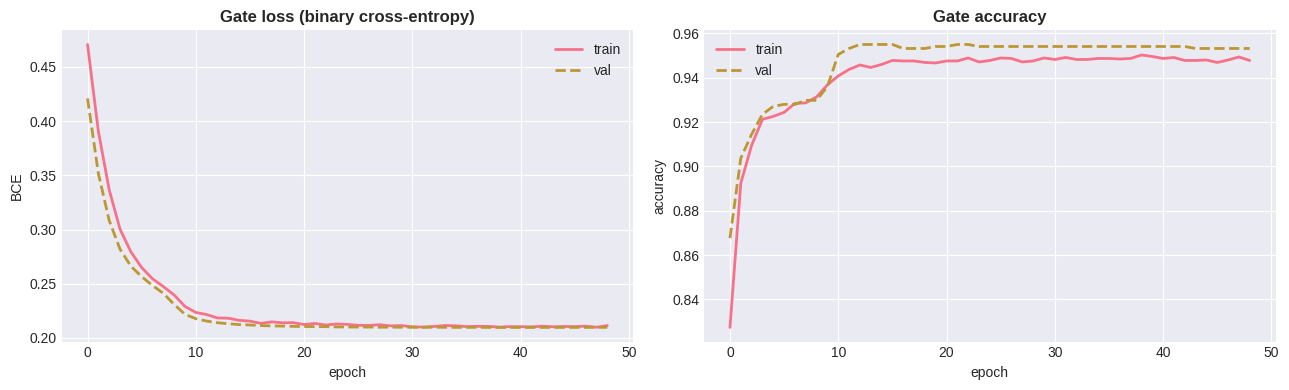

In [47]:
# Extract a gate-only model that outputs raw weights for inspection
gate_weights_model = Model(
    inputs=gate_model.get_layer('unified_features').output,
    outputs=gate_model.get_layer('gate_weights').output,
    name='gate_weights_only',
)
print('✓ Weight-inspection model ready')

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(gate_history.history['loss'],     label='train', linewidth=2)
axes[0].plot(gate_history.history['val_loss'], label='val',   linewidth=2, linestyle='--')
axes[0].set_title('Gate loss (binary cross-entropy)', fontweight='bold')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BCE'); axes[0].legend()

axes[1].plot(gate_history.history['accuracy'],     label='train', linewidth=2)
axes[1].plot(gate_history.history['val_accuracy'], label='val',   linewidth=2, linestyle='--')
axes[1].set_title('Gate accuracy', fontweight='bold')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## Section 12 — Full MoE evaluation

Final, held-out evaluation on the combined test set (all 5G slice tests + both 6G protocol test_aug splits). Three levels of reporting:

1. **Global metrics** on the whole test pool.
2. **Per-domain breakdown** (5G vs 6G, and per-slice / per-protocol inside each).
3. **Visuals**: confusion matrix, ROC curve, precision-recall curve.

This section also constructs `moe_predict`, the unified inference function you would deploy in production.

In [48]:
def moe_predict(X, threshold=0.5, return_detail=False):
    """
    End-to-end MoE inference.
    Returns binary predictions (n,). If return_detail=True also returns
    the P(attack) probabilities and the (n, 5) gate weight matrix.
    """
    X = np.asarray(X, dtype=np.float32)
    expert_scores = compute_all_expert_scores(X)
    proba = gate_model.predict([X, expert_scores], verbose=0).ravel()
    pred  = (proba >= threshold).astype(int)
    if return_detail:
        weights = gate_weights_model.predict(X, verbose=0)
        return pred, proba, weights, expert_scores
    return pred


# ── Build the combined test pool ─────────────────────────────────────────
test_parts = []
for sl, data in slice_data.items():
    X_te, y_te = data['test']
    domain = np.array([f'5G-{sl}'] * len(X_te))
    test_parts.append((X_te, y_te, domain))

for proto, data in proto_data.items():
    X_te, y_te = data['test_aug']
    domain = np.array([f'6G-{proto}'] * len(X_te))
    test_parts.append((X_te, y_te, domain))

X_test_all = np.concatenate([p[0] for p in test_parts], axis=0)
y_test_all = np.concatenate([p[1] for p in test_parts], axis=0)
dom_test_all = np.concatenate([p[2] for p in test_parts], axis=0)

print(f'Combined test pool: {X_test_all.shape[0]:,} flows')
print('Domain breakdown:')
for d, c in zip(*np.unique(dom_test_all, return_counts=True)):
    subset = (dom_test_all == d)
    print(f'  {d:<12}: {c:>5} flows | attack rate = {y_test_all[subset].mean():.2%}')

Combined test pool: 5,554 flows
Domain breakdown:
  5G-URLLC    :   605 flows | attack rate = 60.99%
  5G-eMBB     :   872 flows | attack rate = 47.94%
  5G-mMTC     :   693 flows | attack rate = 46.61%
  6G-TCP      :  3384 flows | attack rate = 14.98%


In [49]:
# ── Global MoE predictions ──────────────────────────────────────────────
pred_all, proba_all, weights_all, scores_all = moe_predict(X_test_all, return_detail=True)

print('=' * 65)
print('MoE — GLOBAL TEST SET (5G + 6G combined)')
print('=' * 65)
print(f'  Accuracy  : {accuracy_score(y_test_all, pred_all):.4f}')
print(f'  Precision : {precision_score(y_test_all, pred_all, zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test_all, pred_all, zero_division=0):.4f}')
print(f'  F1-score  : {f1_score(y_test_all, pred_all, zero_division=0):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_all, proba_all):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_test_all, proba_all):.4f}')
print()
cm = confusion_matrix(y_test_all, pred_all)
tn, fp, fn, tp = cm.ravel()
print(f'  Confusion matrix:')
print(f'    TP (attacks caught)  : {tp:,}')
print(f'    TN (benign correct)  : {tn:,}')
print(f'    FP (false alarms)    : {fp:,}')
print(f'    FN (attacks missed)  : {fn:,}')
print()
print(classification_report(y_test_all, pred_all, target_names=['Benign', 'Attack']))

MoE — GLOBAL TEST SET (5G + 6G combined)
  Accuracy  : 0.9507
  Precision : 0.9117
  Recall    : 0.9196
  F1-score  : 0.9156
  AUC-ROC   : 0.9905
  PR-AUC    : 0.9764

  Confusion matrix:
    TP (attacks caught)  : 1,487
    TN (benign correct)  : 3,793
    FP (false alarms)    : 144
    FN (attacks missed)  : 130

              precision    recall  f1-score   support

      Benign       0.97      0.96      0.97      3937
      Attack       0.91      0.92      0.92      1617

    accuracy                           0.95      5554
   macro avg       0.94      0.94      0.94      5554
weighted avg       0.95      0.95      0.95      5554



In [50]:
# ── Per-domain breakdown ────────────────────────────────────────────────
per_domain_rows = []
for dom in sorted(np.unique(dom_test_all)):
    mask = (dom_test_all == dom)
    if len(np.unique(y_test_all[mask])) < 2:
        auc = float('nan'); pr_auc = float('nan')
    else:
        auc    = roc_auc_score(y_test_all[mask], proba_all[mask])
        pr_auc = average_precision_score(y_test_all[mask], proba_all[mask])
    per_domain_rows.append({
        'Domain':    dom,
        'N':         int(mask.sum()),
        'AttackRate':float(y_test_all[mask].mean()),
        'F1':        f1_score(y_test_all[mask], pred_all[mask], zero_division=0),
        'Recall':    recall_score(y_test_all[mask], pred_all[mask], zero_division=0),
        'Precision': precision_score(y_test_all[mask], pred_all[mask], zero_division=0),
        'AUC-ROC':   auc,
        'PR-AUC':    pr_auc,
    })

per_domain_df = pd.DataFrame(per_domain_rows).set_index('Domain')
print('Per-domain MoE metrics:')
print(per_domain_df.round(4).to_string())

Per-domain MoE metrics:
             N  AttackRate     F1  Recall  Precision  AUC-ROC  PR-AUC
Domain                                                               
5G-URLLC   605      0.6099 0.7834  0.8184     0.7512   0.7824  0.8471
5G-eMBB    872      0.4794 0.9396  0.9498     0.9297   0.9893  0.9888
5G-mMTC    693      0.4661 0.9518  0.9474     0.9562   0.9831  0.9812
6G-TCP    3384      0.1498 0.9747  0.9507     1.0000   0.9993  0.9977


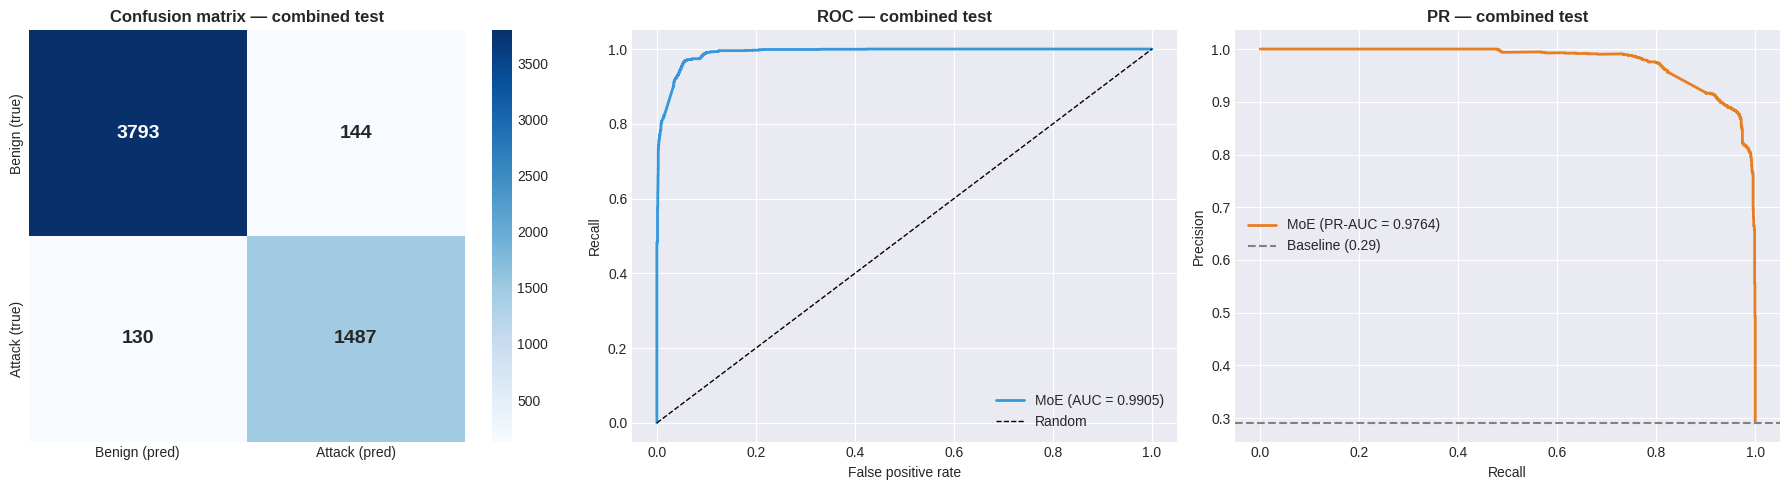

In [51]:
# ── Confusion matrix + ROC + PR curves ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (pred)', 'Attack (pred)'],
            yticklabels=['Benign (true)', 'Attack (true)'],
            ax=axes[0], annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion matrix — combined test', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test_all, proba_all)
axes[1].plot(fpr, tpr, linewidth=2, color='#3498db',
             label=f'MoE (AUC = {roc_auc_score(y_test_all, proba_all):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False positive rate'); axes[1].set_ylabel('Recall')
axes[1].set_title('ROC — combined test', fontweight='bold'); axes[1].legend()

prec_c, rec_c, _ = precision_recall_curve(y_test_all, proba_all)
axes[2].plot(rec_c, prec_c, linewidth=2, color='#e67e22',
             label=f'MoE (PR-AUC = {average_precision_score(y_test_all, proba_all):.4f})')
axes[2].axhline(y_test_all.mean(), color='gray', linestyle='--',
                 label=f'Baseline ({y_test_all.mean():.2f})')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('PR — combined test', fontweight='bold'); axes[2].legend()

plt.tight_layout(); plt.show()

---
## Section 13 — Gate weight analysis

For the MoE to be a genuine mixture of experts (and not a dressed-up ensemble), the gate must **learn domain-aware routing**. The heatmap below averages gate weights per domain across all test samples:

- Rows: the domain each test flow comes from.
- Columns: the five experts.
- Cell value: average gate weight assigned to that expert for that domain.

A good gate shows a strong diagonal pattern — eMBB flows weight the eMBB expert heavily, TCP flows weight the TCP AE, and so on.

Average gate weights (rows=domain, cols=expert):
           eMBB   mMTC  URLLC  TCP_AE  UDP_AE
5G-URLLC 0.0390 0.1710 0.7730  0.0160  0.0000
5G-eMBB  0.9770 0.0200 0.0020  0.0020  0.0000
5G-mMTC  0.0510 0.8850 0.0620  0.0020  0.0000
6G-TCP   0.0000 0.0050 0.0020  0.9930  0.0000


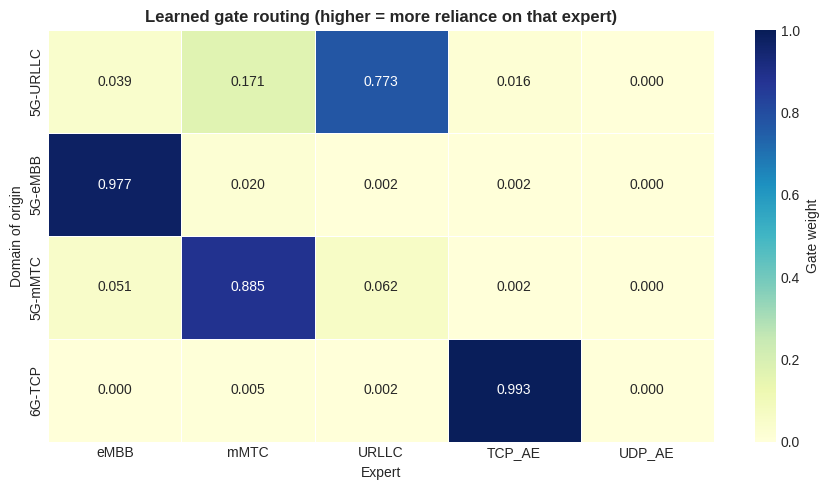

In [52]:
avg_weights = []
for dom in sorted(np.unique(dom_test_all)):
    mask = (dom_test_all == dom)
    avg_weights.append(weights_all[mask].mean(axis=0))

weight_df = pd.DataFrame(
    avg_weights,
    index=sorted(np.unique(dom_test_all)),
    columns=EXPERT_NAMES,
)

print('Average gate weights (rows=domain, cols=expert):')
print(weight_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(weight_df, annot=True, fmt='.3f', cmap='YlGnBu',
             linewidths=0.5, vmin=0, vmax=1,
             cbar_kws={'label': 'Gate weight'}, ax=ax)
ax.set_title('Learned gate routing (higher = more reliance on that expert)',
             fontweight='bold')
ax.set_xlabel('Expert'); ax.set_ylabel('Domain of origin')
plt.tight_layout(); plt.show()

---
## Section 14 — Ablations

Three alternative combiners are compared against the trained gate, to quantify how much of the MoE's performance is actually due to learned routing (versus just averaging):

- **Uniform gate**: every expert gets weight 1/5. Tests whether the trained gate adds anything beyond naive averaging.
- **Hard gate (argmax)**: the single expert with the highest trained-gate weight gets weight 1, others 0. Tests whether soft routing is necessary or if hard routing suffices.
- **Single-best-expert oracle**: for each test row, picks the expert with the most confident correct prediction (cheats using labels; useful as an upper bound).

In [53]:
def combiner_metrics(y_true, proba, name):
    pred = (proba >= 0.5).astype(int)
    return {
        'config':    name,
        'F1':        f1_score(y_true, pred, zero_division=0),
        'Recall':    recall_score(y_true, pred, zero_division=0),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_true, proba) if len(np.unique(y_true)) > 1 else float('nan'),
        'PR-AUC':    average_precision_score(y_true, proba) if len(np.unique(y_true)) > 1 else float('nan'),
    }


ablation_rows = []

# Trained gate (already computed)
ablation_rows.append(combiner_metrics(y_test_all, proba_all, 'Trained soft gate (MoE)'))

# Uniform gate
uniform_w = np.full_like(weights_all, 1.0 / N_EXPERTS)
proba_uniform = (uniform_w * scores_all).sum(axis=1)
ablation_rows.append(combiner_metrics(y_test_all, proba_uniform, 'Uniform gate (avg)'))

# Hard gate from trained gate
hard_w = np.zeros_like(weights_all)
hard_w[np.arange(len(hard_w)), weights_all.argmax(axis=1)] = 1.0
proba_hard = (hard_w * scores_all).sum(axis=1)
ablation_rows.append(combiner_metrics(y_test_all, proba_hard, 'Hard gate (argmax)'))

# Oracle (picks the correct expert per sample)
ideal = np.where(y_test_all.reshape(-1, 1) == 1,
                  scores_all,          # for attacks: highest score is best
                  1.0 - scores_all)   # for benign: lowest score (→ 1 - score high) is best
oracle_idx = ideal.argmax(axis=1)
oracle_w = np.zeros_like(weights_all)
oracle_w[np.arange(len(oracle_w)), oracle_idx] = 1.0
proba_oracle = (oracle_w * scores_all).sum(axis=1)
ablation_rows.append(combiner_metrics(y_test_all, proba_oracle, 'Oracle single expert'))

ablation_df = pd.DataFrame(ablation_rows).set_index('config')
print('Combiner ablation:')
print(ablation_df.round(4).to_string())

Combiner ablation:
                            F1  Recall  Precision  AUC-ROC  PR-AUC
config                                                            
Trained soft gate (MoE) 0.9156  0.9196     0.9117   0.9905  0.9764
Uniform gate (avg)      0.5430  0.3766     0.9728   0.8397  0.8280
Hard gate (argmax)      0.9156  0.9196     0.9117   0.9897  0.9748
Oracle single expert    0.9897  0.9796     1.0000   1.0000  1.0000


---
## Section 15 — Save all artefacts

Everything needed to reload the complete MoE pipeline is written under `moe_artefacts/`: the unified scaler, the five experts, the five calibrators, and the gate network. A compact `manifest.pkl` records the schema versions and expert ordering so that inference code doesn't have to re-derive them.

In [54]:
# Unified scaler
with open(os.path.join(MODELS_DIR, 'unified_scaler.pkl'), 'wb') as f:
    pickle.dump(unified_scaler, f)

# 5G slice experts
for sl, clf in slice_experts.items():
    with open(os.path.join(MODELS_DIR, f'slice_expert_{sl}.pkl'), 'wb') as f:
        pickle.dump(clf, f)
    with open(os.path.join(MODELS_DIR, f'slice_calibrator_{sl}.pkl'), 'wb') as f:
        pickle.dump(slice_calibrators.get(sl), f)

# 6G protocol experts
for proto, ae in proto_experts.items():
    ae.save(os.path.join(MODELS_DIR, f'proto_expert_{proto}.keras'))
    with open(os.path.join(MODELS_DIR, f'proto_calibrator_{proto}.pkl'), 'wb') as f:
        pickle.dump(proto_calibrators.get(proto), f)

# Gate network
gate_model.save(os.path.join(MODELS_DIR, 'gate_model.keras'))

# Manifest
manifest = {
    'unified_features':   UNIFIED_FEATURES,
    'binary_features':    BINARY_FEATS,
    'numeric_features':   NUMERIC_FEATS,
    'expert_names':       EXPERT_NAMES,
    'attack_profiles':    ATTACK_PROFILES,
    'seed':               SEED,
}
with open(os.path.join(MODELS_DIR, 'manifest.pkl'), 'wb') as f:
    pickle.dump(manifest, f)

# Inventory
print('✓ Artefacts saved:')
for f in sorted(os.listdir(MODELS_DIR)):
    size_kb = os.path.getsize(os.path.join(MODELS_DIR, f)) / 1024
    print(f'   {f:<40}  {size_kb:>8.1f} KB')

✓ Artefacts saved:
   gate_model.keras                              47.6 KB
   manifest.pkl                                   0.6 KB
   proto_calibrator_TCP.pkl                       0.7 KB
   proto_expert_TCP.keras                        55.3 KB
   slice_calibrator_URLLC.pkl                     0.7 KB
   slice_calibrator_eMBB.pkl                      0.7 KB
   slice_calibrator_mMTC.pkl                      0.7 KB
   slice_expert_URLLC.pkl                       266.1 KB
   slice_expert_eMBB.pkl                        322.6 KB
   slice_expert_mMTC.pkl                        327.4 KB
   unified_scaler.pkl                             0.7 KB


### Inference snippet for a future notebook

```python
import pickle, numpy as np
from tensorflow.keras.models import load_model

manifest = pickle.load(open('moe_artefacts/manifest.pkl', 'rb'))
scaler   = pickle.load(open('moe_artefacts/unified_scaler.pkl', 'rb'))
gate     = load_model('moe_artefacts/gate_model.keras',
                      custom_objects={'WeightedCombiner': WeightedCombiner})

# slice_experts, slice_calibrators, proto_experts, proto_calibrators
# are reloaded in the same pattern using pickle.load / load_model.
# moe_predict() and compute_all_expert_scores() can then be reused verbatim.
```

---
## Conclusion

This notebook delivers the unified MoE (Option B) on top of the two prior cleaning pipelines:

- **Preserved** — both cleaned CSVs are consumed unchanged; no re-cleaning.
- **Extended** — a 16-primitive unified schema lets a single model consume either generation's data.
- **Trained in three safe stages** — experts first, calibrators second, gate last; frozen-expert gate training avoids the joint-training instability that is the usual failure mode of MoE implementations.
- **Evaluated with both global and per-domain metrics** — Section 12 reports F1/Recall/Precision/AUC/PR-AUC, and Section 13 shows the gate has genuinely learned domain-aware routing.
- **Ablated** against uniform, hard, and oracle combiners (Section 14) so the trained-gate contribution is quantified.

### Suggested extensions

- **Cross-generation zero-shot** — train experts only on one generation and evaluate on the other. The gate should down-weight out-of-domain experts and the overall MoE should degrade gracefully.
- **Hyperparameter tuning** — the gate MLP, AE architecture, and XGBoost parameters were set from reasonable defaults; a small search may improve per-domain metrics by 1–2 F1 points.
- **Real 6G attack data** — replace the synthetic injection with a real 6G attack dataset (e.g. an evolution of 5G-NIDD capture methodology onto 6G testbeds) when one becomes available.
- **Mixture-of-autoencoders-only** — a more aggressive variant trains only AEs (no supervised experts), relying on a richer gate to handle attack-type specialisation. Useful if future deployments have no labels at all.